In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [2]:
load_dotenv(override=True)

import os

if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY is missing. Add it to .env and rerun this cell.")

model = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
# create state

class BlogState(TypedDict):

    title : str
    outline : str
    content : str
    rating : str

In [4]:
def create_outline(state : BlogState) -> BlogState:

    title = state['title']

    prompt = f'Generate a detailed outline on this title {title} for my blog'

    model_outline = model.invoke(prompt).content

    state['outline'] = model_outline

    return state 



In [5]:
def create_blog(state : BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Create a detailed blog on the basis of given title - {title} using the following outline \n {outline}'

    model_content = model.invoke(prompt).content

    state['content'] = model_content

    return state 



In [6]:
def evaluate(state : BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']
    content = state['content']

    prompt = f"""Evaluate the following blog written on title: {title}.
                Use the given outline as reference for coverage and structure.
                Give a rating out of 10 and a short reason.

Outline:
{outline}

Blog:
{content}"""

    rating = model.invoke(prompt).content

    state['rating'] = rating

    return state

In [7]:
graph = StateGraph(BlogState)

# add node
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluate',evaluate)

# add edge
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate')
graph.add_edge('evaluate',END)

# compile
workflow = graph.compile()

In [8]:
# excetution
initial_state = {'title' : 'Rise of AI in World'}
final_state = workflow.invoke(initial_state)

In [9]:
print(final_state['content'])
print()
print('Blog Rating:')
print(final_state['rating'])

**The Rise of AI in the World: A Comprehensive Analysis**

**Introduction**

Artificial Intelligence (AI) has revolutionized the world in numerous ways, transforming the way we live, work, and interact with each other. From its early beginnings in the 1950s to its current state of advancements and applications, AI has come a long way. In this comprehensive analysis, we will delve into the history of AI development, its applications in various industries, benefits, challenges, and future directions.

**History of AI Development**

The concept of AI dates back to the 1950s when computer scientists like Alan Turing, John McCarthy, and Marvin Minsky first explored the idea of creating machines that could think and learn like humans. In the 1980s and 1990s, rule-based systems and expert systems emerged, which enabled computers to make decisions based on specific rules and knowledge.

The 2000s marked a significant shift in AI development with the rise of machine learning and deep learning. 

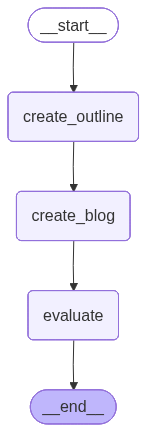

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())